In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , GridSearchCV , cross_val_score , KFold
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score , f1_score
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline


In [13]:
df = pd.read_csv('data/reviews.tsv' , sep= '\t')

print(df.shape)
print(df.head())
print(df["label"].value_counts())

(99999, 2)
      label                                               text
0  Positive  ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
1  Positive  أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...
2  Positive  هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...
3  Positive  خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...
4  Positive  ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...
label
Positive    33333
Mixed       33333
Negative    33333
Name: count, dtype: int64


In [14]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   99999 non-null  str  
 1   text    99999 non-null  str  
dtypes: str(2)
memory usage: 1.5 MB
None
           label                                               text
count      99999                                              99999
unique         3                                              99999
top     Positive  ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
freq       33333                                                  1


In [17]:
df["length"] = df["text"].astype(str).str.split().apply(len)
display(df["length"].describe())

display(df.groupby("label")["length"].describe())

count    99999.000000
mean        55.026010
std         95.495538
min          1.000000
25%         13.000000
50%         26.000000
75%         57.000000
max       1663.000000
Name: length, dtype: float64

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Mixed,33333.0,55.701317,92.953663,1.0,13.0,27.0,59.0,1663.0
Negative,33333.0,55.021120,93.352397,1.0,13.0,28.0,58.0,1622.0
Positive,33333.0,54.355594,100.013906,1.0,11.0,24.0,54.0,1580.0


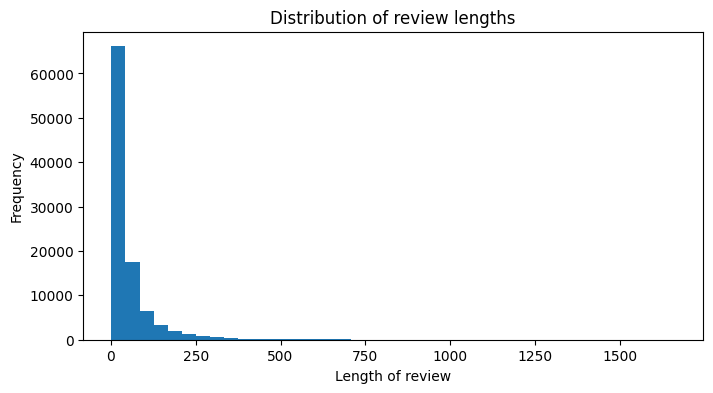

In [18]:
plt.figure(figsize=(8,4))
plt.hist(df["length"] , bins = 40)
plt.title("Distribution of review lengths")
plt.xlabel("Length of review")
plt.ylabel("Frequency")
plt.show()


In [ ]:
X = df["text"]
y = df["label"]

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42 , stratify=y)

In [ ]:
model = Sequential([
    Dense(128 , activation='relu' , input_shape=(X.shape[1],)),
    Dense(64 , activation='relu'),
    Dense(3 , activation='sigmoid')
])

bow_model = Pipeline([
    ("vectorizer" , CountVectorizer()),
    ("classifier" , model)
])
